In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

path = "../images/mosketeers.jpg"
originale_bgr = cv2.imread(path)

if originale_bgr is None:
    raise FileNotFoundError("Immagine non trovata! Controlla il percorso.")

gray = cv2.cvtColor(originale_bgr, cv2.COLOR_BGR2GRAY)
gray_float = np.float32(gray)

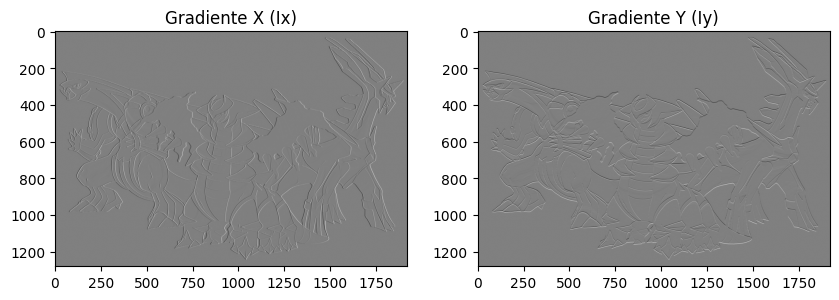

In [10]:
# Calcolo derivate I_x e I_y
ix = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
iy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)

# Calcolo dei prodotti delle derivate per la matrice M
ix2 = ix**2
iy2 = iy**2
ixiy = ix*iy

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(ix, cmap='gray')
ax[0].set_title("Gradiente X (Ix)")
ax[1].imshow(iy, cmap='gray')
ax[1].set_title("Gradiente Y (Iy)")
plt.show()

In [11]:
# Applichiamo un filtro Gaussiano per simulare la finestra W
window_size = 3
ix2 = cv2.GaussianBlur(ix2, (window_size, window_size), 0)
iy2 = cv2.GaussianBlur(iy2, (window_size, window_size), 0)
ixiy = cv2.GaussianBlur(ixiy, (window_size, window_size), 0)

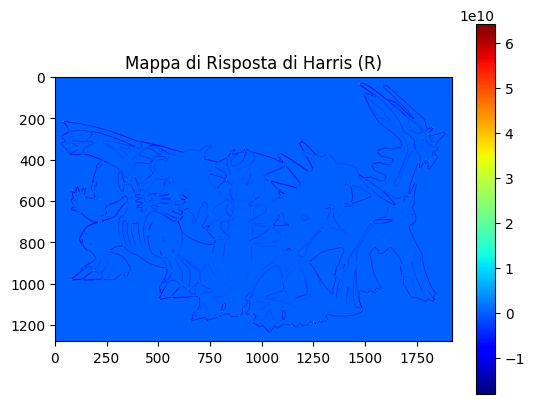

In [12]:
# Parametro k (solitamente tra 0.04 e 0.06)
k = 0.04

# Determinante e Traccia della matrice M
det_M = (ix2 * iy2) - (ixiy**2)
trace_M = ix2 + iy2

# Harris Response
R = det_M - k * (trace_M**2)

plt.imshow(R, cmap='jet')
plt.colorbar()
plt.title("Mappa di Risposta di Harris (R)")
plt.show()

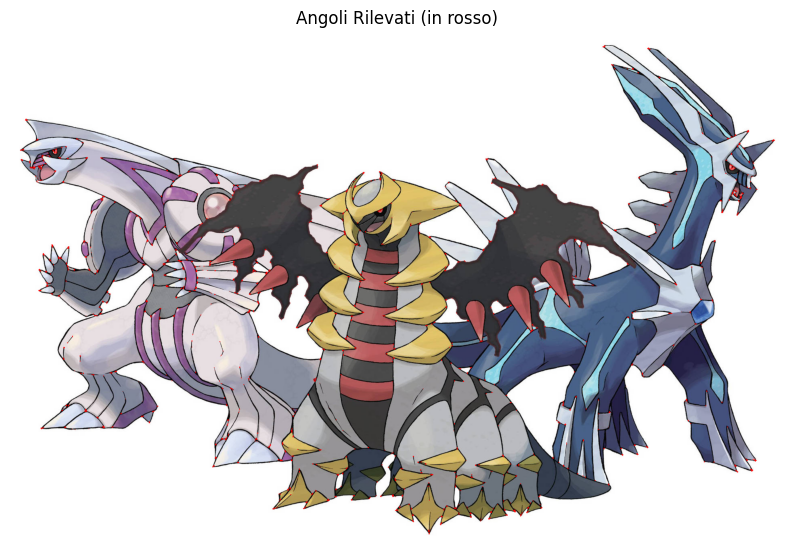

In [15]:
# 1. NON convertire da Grigio a BGR (perché è già a colori!)
# Facciamo una copia dell'immagine originale a colori
img_display = originale_bgr.copy()

# 2. Convertiamola da BGR a RGB solo per vederla bene con Matplotlib
img_display = cv2.cvtColor(img_display, cv2.COLOR_BGR2RGB)

# 3. Soglia (usa il nome della variabile R che hai calcolato prima)
# Se nella cella sopra l'hai chiamata R_mappa, usa R_mappa qui.
threshold = 0.01 * R.max()

# 4. Troviamo i punti sopra la soglia e coloriamoli di ROSSO
# Ora le dimensioni combaciano perfettamente
img_display[R > threshold] = [255, 0, 0]

# 5. Visualizzazione
plt.figure(figsize=(10, 10))
plt.imshow(img_display)
plt.title("Angoli Rilevati (in rosso)")
plt.axis('off')
plt.show()

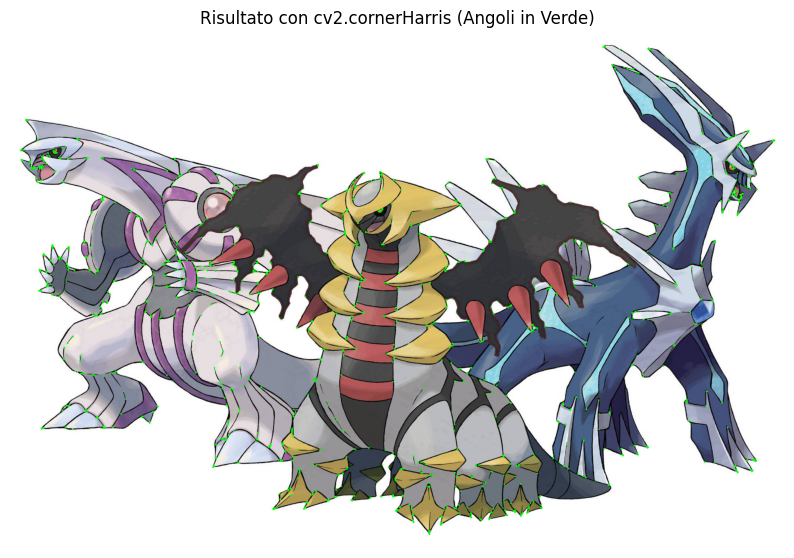

In [18]:
# 1. Calcolo Harris con funzione OpenCV
# 'gray' deve essere l'immagine in scala di grigi float32 (quella dei moschettieri)
dst = cv2.cornerHarris(gray, blockSize=2, ksize=3, k=0.04)

# 2. Dilatiamo il risultato (i puntini diventano più grandi e visibili)
dst = cv2.dilate(dst, None)

# 3. CREAZIONE IMMAGINE FINALE
# NON usare cv2.cvtColor! img_display è già a colori. Fai solo una copia.
img_final = img_display.copy()

# 4. Coloriamo gli angoli di VERDE [0, 255, 0]
# Usiamo una soglia (es. 1% del valore massimo trovato da Harris)
img_final[dst > 0.01 * dst.max()] = [0, 255, 0]

# 5. Visualizzazione
plt.figure(figsize=(10, 10))
plt.imshow(img_final)
plt.title("Risultato con cv2.cornerHarris (Angoli in Verde)")
plt.axis('off')
plt.show()